In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")
print(df.head())
print("\nDataset Overview:")
df.info()

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-01-2020          M                              5.48   
1  Andhra Pradesh   29-02-2020          M                              5.83   
2  Andhra Pradesh   31-03-2020          M                              5.79   
3  Andhra Pradesh   30-04-2020          M                             20.51   
4  Andhra Pradesh   31-05-2020          M                             17.43   

    Estimated Employed   Estimated Labour Participation Rate (%) Region.1  \
0             16635535                                     41.02    South   
1             16545652                                     40.90    South   
2             15881197                                     39.18    South   
3             11336911                                     33.10    South   
4             12988845                                     36.46    South   

   longitude  latitude  
0    15.9129     79.74  
1    15.9129

In [20]:
# Check for missing values in dataset
print("\nMissing Values in Dataset:")
print(df.isnull().sum())

# Standardize column names by removing spaces and converting to lowercase
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Display statistical summary of dataset
print("\nDataset Summary:")
print(df.describe())



Missing Values in Dataset:
Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64

Dataset Summary:
       estimated_unemployment_rate_(%)  estimated_employed  \
count                       267.000000        2.670000e+02   
mean                         12.236929        1.396211e+07   
std                          10.803283        1.336632e+07   
min                           0.500000        1.175420e+05   
25%                           4.845000        2.838930e+06   
50%                           9.650000        9.732417e+06   
75%                          16.755000        2.187869e+07   
max                          75

In [22]:
print("\nList of Regions in Dataset:", df['region'].unique())
region_col = 'region'
unemployment_col = 'estimated_unemployment_rate_(%)'
regionwise_unemployment = df.groupby(region_col)[unemployment_col].mean().sort_values()
print("\nTop 5 Regions with Highest Unemployment:")
print(regionwise_unemployment.tail())
print("\nTop 5 Regions with Lowest Unemployment:")
print(regionwise_unemployment.head())


List of Regions in Dataset: ['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal']

Top 5 Regions with Highest Unemployment:
region
Delhi        18.414
Bihar        19.471
Jharkhand    19.539
Tripura      25.055
Haryana      27.477
Name: estimated_unemployment_rate_(%), dtype: float64

Top 5 Regions with Lowest Unemployment:
region
Meghalaya    3.866
Assam        4.856
Gujarat      6.376
Odisha       6.462
Telangana    6.833
Name: estimated_unemployment_rate_(%), dtype: float64


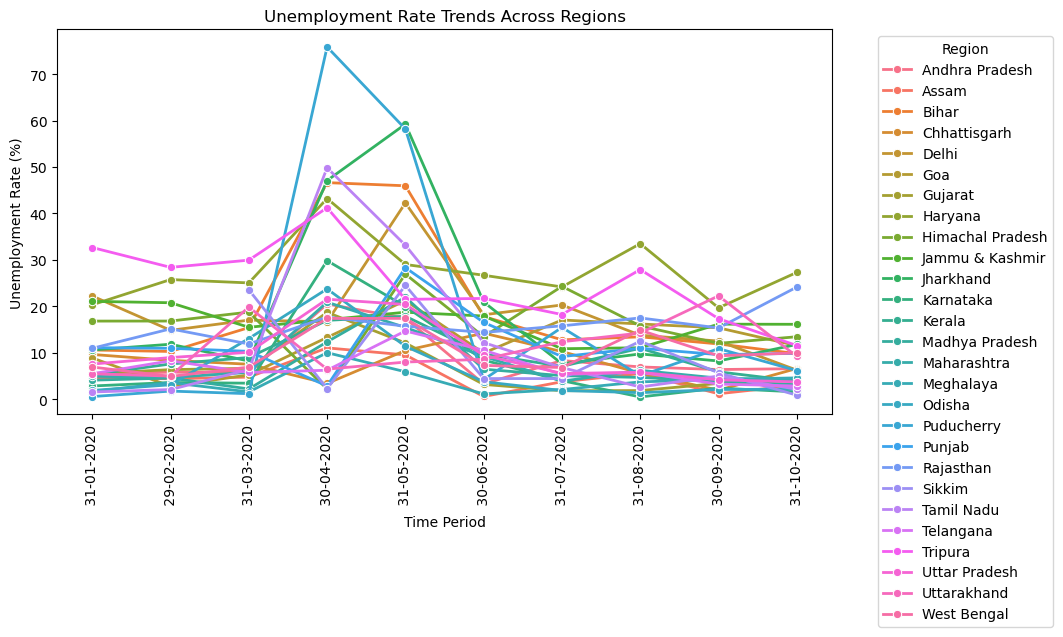

In [24]:
plt.figure(figsize=(10, 5))
sns.lineplot(x=df['date'], y=df[unemployment_col], hue=df['region'], marker="o", linewidth=2)
plt.xticks(rotation=90)
plt.xlabel("Time Period")
plt.ylabel("Unemployment Rate (%)")
plt.title("Unemployment Rate Trends Across Regions")
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

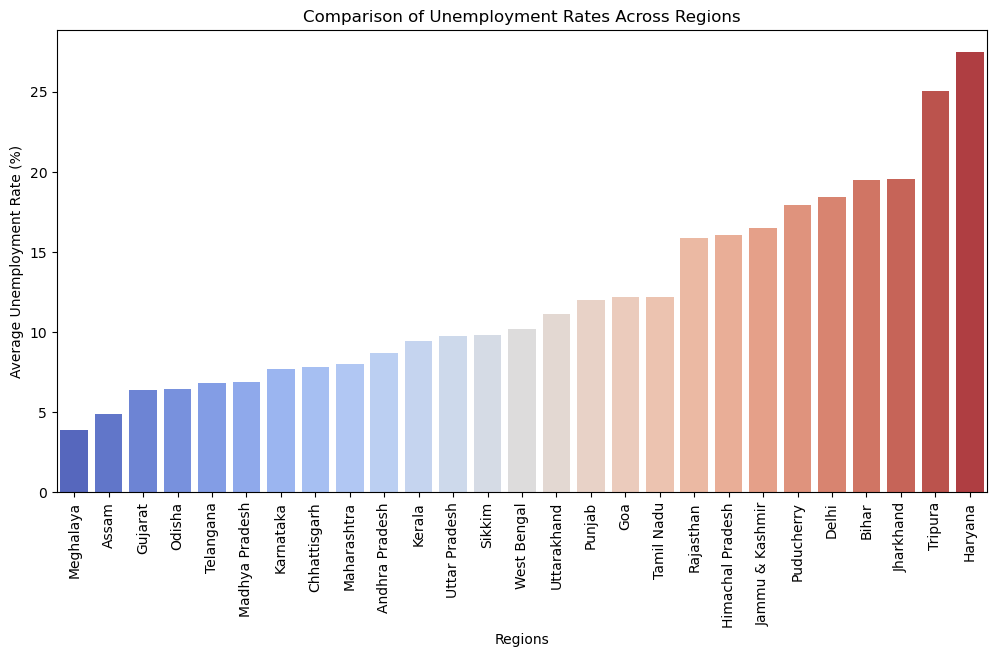

In [26]:
plt.figure(figsize=(12, 6))
sns.barplot(x=regionwise_unemployment.index, y=regionwise_unemployment.values, hue=regionwise_unemployment.index, dodge=False, palette="coolwarm", legend=False)
plt.xticks(rotation=90)
plt.xlabel("Regions")
plt.ylabel("Average Unemployment Rate (%)")
plt.title("Comparison of Unemployment Rates Across Regions")
plt.show()